In [2]:
import networkx as nx
from networkx.readwrite import json_graph
from gerrychain import Graph
import matplotlib.pyplot as plt
import requests
import json
import maup
import geopandas as gpd

In [3]:
alarm = gpd.read_file("./SC_ALARM/sc_alarm.shp")

<Axes: >

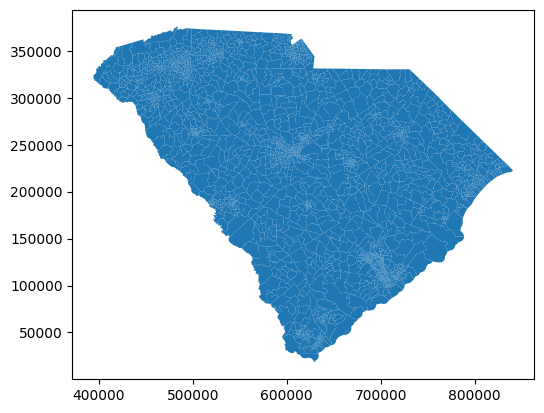

In [4]:
alarm.plot()

In [5]:
CON = gpd.read_file("./sc_cong_adopted_2022/S865_Congress.shp")
SLDL = gpd.read_file("./sc_sldl_adopted_2024_shp/S1024.shp")
SLDU = gpd.read_file("./sc_sldu_2021/sc_sldu_2021.shp")

In [6]:
CON = CON.to_crs(alarm.crs)
SLDU = SLDU.to_crs(alarm.crs)
SLDL = SLDL.to_crs(alarm.crs)


bk_to_CON = maup.assign(alarm,CON)
bk_to_SLDU = maup.assign(alarm,SLDU.to_crs(alarm.crs))
bk_to_SLDL = maup.assign(alarm,SLDL.to_crs(alarm.crs))

In [7]:
alarm["CON"] = bk_to_CON
alarm["SLDU"] = bk_to_SLDU
alarm["SLDL"] = bk_to_SLDL

(371616.90050833, 863374.3231278701, 164.5251800149963, 393815.45853008504)

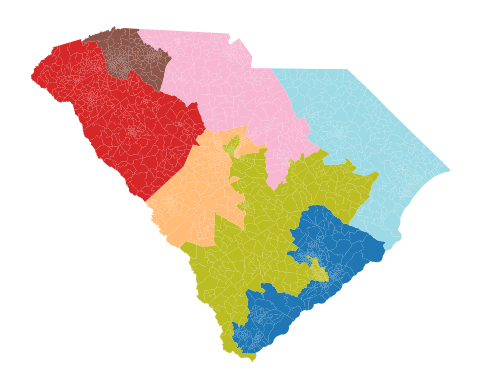

In [8]:
alarm.plot(column="CON",cmap='tab20')
plt.axis('off')

In [9]:
alarm['C_X'] = alarm.centroid.x
alarm['C_Y'] = alarm.centroid.y

In [ ]:
precinct_graph = Graph.from_geodataframe(alarm)


alarm.to_file("./output/SC_Processed_Precincts_ALARM.shp")

precinct_graph.to_json("./output/SC_Processed_Precincts_ALARM.json")

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\gerrychain\graph\graph.py:457: UserWarning: NA values found in column muni!
  warnings.warn("NA values found in column {}!".format(column))
